<a href="https://colab.research.google.com/github/belinatom/NALAPROJECT/blob/main/nlp_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✓ Setup complete | Device: {device}')

✓ Setup complete | Device: cuda


In [ ]:
print("""
=============================================================
WHY BERT OVER TASK 1 METHODS?
=============================================================

Task 1 used static representations:
  - TF-IDF:     Bag-of-words, no word order, no context
  - Word2Vec:   Static embeddings, same vector regardless of context
  - FastText:   Subword-aware but still static
  - Char N-grams: Character patterns, no semantic meaning

BERT improvements:
  - Contextual embeddings: same word = different vector per context
  - Transfer learning: pretrained on massive corpora
  - Attention mechanism: captures long-range dependencies
  - Fine-tuning: adapts pretrained knowledge to our task

Model selection rationale:
  ┌─────────────────────────────────────────────────────┐
  │ 1. DistilBERT-multilingual                          │
  │    → Standard multilingual BERT baseline            │
  │    → 104 languages including Swahili                │
  │    → Direct comparison to Task 1                    │
  │                                                     │
  │ 2. SwahBERT                                         │
  │    → Monolingual Swahili BERT                       │
  │    → Trained on Swahili news, Wikipedia, forums     │
  │    → Purpose-built for our exact language           │
  │                                                     │
  │ 3. AfriBERTa-Large                                  │
  │    → Multilingual African language model            │
  │    → Trained on 11 African languages incl. Swahili  │
  │    → Best balance: African context + multilingual   │
  └─────────────────────────────────────────────────────┘
""")


WHY BERT OVER TASK 1 METHODS?

Task 1 used static representations:
  - TF-IDF:     Bag-of-words, no word order, no context
  - Word2Vec:   Static embeddings, same vector regardless of context
  - FastText:   Subword-aware but still static
  - Char N-grams: Character patterns, no semantic meaning

BERT improvements:
  - Contextual embeddings: same word = different vector per context
  - Transfer learning: pretrained on massive corpora
  - Attention mechanism: captures long-range dependencies
  - Fine-tuning: adapts pretrained knowledge to our task

Model selection rationale:
  ┌─────────────────────────────────────────────────────┐
  │ 1. DistilBERT-multilingual                          │
  │    → Standard multilingual BERT baseline            │
  │    → 104 languages including Swahili                │
  │    → Direct comparison to Task 1                    │
  │                                                     │
  │ 2. SwahBERT                                         │
  │    → Mon

In [ ]:
df = pd.read_csv('/content/swahiliproverbs.csv')
df = df[['swahili_proverb', 'label']].dropna().copy()
df['swahili_proverb'] = df['swahili_proverb'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()
df = df[df['swahili_proverb'] != ''].reset_index(drop=True)

print(f'✓ Loaded: {len(df)} proverbs, {df["label"].nunique()} categories')
df.head(5)

✓ Loaded: 5060 proverbs, 56 categories


,swahili_proverb,label
0,Achekaye kilema hata kwao kipo.,Abuse
1,Afadhali lawama ya wazi.,Abuse
2,Afanyae mzaha na watu humlazimu awe na saburi.,Abuse
3,Ajabu ya kondoo kucheka kioo.,Abuse
4,Ajabu ya ngamia kucheka nundu ya ng'ombe.,Abuse


In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['label'])
x = df['swahili_proverb'].values
num_classes = len(le.classes_)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=seed, stratify=y_train
)

print(f'✓ Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}')
print(f'✓ Classes: {num_classes}')

✓ Train: 3643 | Val: 405 | Test: 1012
✓ Classes: 56


In [ ]:
MAX_LENGTH = 64
BATCH_SIZE = 32

def make_loader(input_ids, attention_mask, labels, shuffle=False):
    dataset = TensorDataset(
        input_ids,
        attention_mask,
        torch.tensor(labels, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)

print('✓ DataLoader helper defined')

✓ DataLoader helper defined


In [ ]:
def run_experiment(config_name, lr, num_epochs, model_name):
    print(f'\n{"="*60}')
    print(f'MODEL:  {config_name}')
    print(f'SOURCE: {model_name}')
    print(f'LR:     {lr} | Epochs: {num_epochs}')
    print(f'{"="*60}')

    # Load tokenizer & tokenize
    tok = AutoTokenizer.from_pretrained(model_name)

    def tokenize(texts):
        enc = tok(texts.tolist(), max_length=MAX_LENGTH,
                  truncation=True, padding=True, return_tensors='pt')
        return enc['input_ids'], enc['attention_mask']

    tr_ids, tr_masks = tokenize(x_train)
    vl_ids, vl_masks = tokenize(x_val)
    te_ids, te_masks = tokenize(x_test)

    tr_loader = make_loader(tr_ids, tr_masks, y_train, shuffle=True)
    vl_loader = make_loader(vl_ids, vl_masks, y_val)
    te_loader = make_loader(te_ids, te_masks, y_test)

    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_classes,
        ignore_mismatched_sizes=True
    ).to(device)

    optimizer   = AdamW(model.parameters(), lr=lr)
    total_steps = len(tr_loader) * num_epochs
    scheduler   = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

    history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_acc = 0

    for epoch in range(num_epochs):
        # Train
        model.train()
        total_loss = 0
        for input_ids, attention_mask, labels in tr_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels         = labels.to(device)
            optimizer.zero_grad()
            loss = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        train_loss = total_loss / len(tr_loader)

        # Validate
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for input_ids, attention_mask, labels in vl_loader:
                input_ids      = input_ids.to(device)
                attention_mask = attention_mask.to(device)
                logits = model(input_ids=input_ids,
                              attention_mask=attention_mask).logits
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                targets.extend(labels.numpy())

        val_acc = accuracy_score(targets, preds)
        val_f1  = f1_score(targets, preds, average='macro', zero_division=0)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1  = val_f1
            torch.save(model.state_dict(), f'/tmp/best_{config_name.replace(" ", "_")}.pth')

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'  Epoch {epoch+1}/{num_epochs} | '
              f'Loss={train_loss:.4f} | '
              f'Val Acc={val_acc:.4f} | '
              f'Val F1={val_f1:.4f}')

    # Test with best model
    model.load_state_dict(
        torch.load(f'/tmp/best_{config_name.replace(" ", "_")}.pth')
    )
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in te_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            logits = model(input_ids=input_ids,
                          attention_mask=attention_mask).logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets.extend(labels.numpy())

    test_acc = accuracy_score(targets, preds)
    test_f1  = f1_score(targets, preds, average='macro', zero_division=0)

    print(f'\n✓ {config_name}')
    print(f'  Best Val Acc={best_val_acc:.4f} | Best Val F1={best_val_f1:.4f}')
    print(f'  Test Acc={test_acc:.4f}     | Test F1={test_f1:.4f}')

    return {
        'config':        config_name,
        'model':         model_name,
        'lr':            lr,
        'epochs':        num_epochs,
        'best_val_acc':  best_val_acc,
        'best_val_f1':   best_val_f1,
        'test_acc':      test_acc,
        'test_f1':       test_f1,
        'history':       history
    }

print('✓ Training function defined')

✓ Training function defined


In [ ]:
import gdown
import os
import shutil

os.makedirs('/content/swahbert', exist_ok=True)

print('Downloading SwahBERT-Cased from Google Drive...')
gdown.download_folder(
    'https://drive.google.com/drive/folders/1cCcPopqTyzY6AnH9quKcT9kG5zH7tgEZ',
    output='/content/swahbert',
    quiet=False
)

# Rename config
shutil.copy('/content/swahbert/swahbert_config.json',
            '/content/swahbert/config.json')

print('✓ SwahBERT ready!')
print(os.listdir('/content/swahbert'))

Retrieving folder contents


Processing file 1Z-EW5BXSuX7tLXTkUrAtmQuKyd8fgvDy pytorch_model.bin
Processing file 13JH-ersMiaTI3JES-DPoWejgtFfpx7CQ swahbert_config.json
Processing file 1DoGtz93DlADOMpVeVjCUTujFKPxt-4-w vocab.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1Z-EW5BXSuX7tLXTkUrAtmQuKyd8fgvDy
From (redirected): https://drive.google.com/uc?id=1Z-EW5BXSuX7tLXTkUrAtmQuKyd8fgvDy&confirm=t&uuid=defa4452-ca97-4bd9-9d1b-bc4d7ea27d51
To: /content/swahbert/pytorch_model.bin
100%|██████████| 445M/445M [00:11<00:00, 39.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=13JH-ersMiaTI3JES-DPoWejgtFfpx7CQ
To: /content/swahbert/swahbert_config.json
100%|██████████| 313/313 [00:00<00:00, 1.30MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DoGtz93DlADOMpVeVjCUTujFKPxt-4-w
To: /content/swahbert/vocab.txt
100%|██████████| 283k/283k [00:00<00:00, 29.7MB/s]

✓ SwahBERT ready!
['vocab.txt', 'config.json', 'swahbert_config.json', 'pytorch_model.bin']



Download completed


In [ ]:
print('='*60)
print('EXPERIMENT 1: DistilBERT-Multilingual')
print('Hyperparameter search: LR and Epochs')
print('='*60)

# Config A: 3 epochs, LR=2e-5
result_distil_a = run_experiment(
    config_name = 'DistilBERT (3ep, lr=2e-5)',
    lr          = 2e-5,
    num_epochs  = 3,
    model_name  = 'distilbert-base-multilingual-cased'
)

EXPERIMENT 1: DistilBERT-Multilingual
Hyperparameter search: LR and Epochs

MODEL:  DistilBERT (3ep, lr=2e-5)
SOURCE: distilbert-base-multilingual-cased
LR:     2e-05 | Epochs: 3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 | Loss=3.9426 | Val Acc=0.0494 | Val F1=0.0017
  Epoch 2/3 | Loss=3.8638 | Val Acc=0.0667 | Val F1=0.0078
  Epoch 3/3 | Loss=3.8125 | Val Acc=0.0790 | Val F1=0.0103

✓ DistilBERT (3ep, lr=2e-5)
  Best Val Acc=0.0790 | Best Val F1=0.0103
  Test Acc=0.0692     | Test F1=0.0101


In [ ]:
# Config B: 10 epochs, LR=3e-5
result_distil_b = run_experiment(
    config_name = 'DistilBERT (10ep, lr=3e-5)',
    lr          = 3e-5,
    num_epochs  = 10,
    model_name  = 'distilbert-base-multilingual-cased'
)


MODEL:  DistilBERT (10ep, lr=3e-5)
SOURCE: distilbert-base-multilingual-cased
LR:     3e-05 | Epochs: 10


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/10 | Loss=3.9235 | Val Acc=0.0593 | Val F1=0.0051
  Epoch 2/10 | Loss=3.8130 | Val Acc=0.0815 | Val F1=0.0245
  Epoch 3/10 | Loss=3.6537 | Val Acc=0.1210 | Val F1=0.0393
  Epoch 4/10 | Loss=3.4280 | Val Acc=0.1481 | Val F1=0.0666
  Epoch 5/10 | Loss=3.2037 | Val Acc=0.1654 | Val F1=0.0800
  Epoch 6/10 | Loss=2.9836 | Val Acc=0.1728 | Val F1=0.0856
  Epoch 7/10 | Loss=2.8111 | Val Acc=0.1679 | Val F1=0.0832
  Epoch 8/10 | Loss=2.6403 | Val Acc=0.1778 | Val F1=0.0896
  Epoch 9/10 | Loss=2.5288 | Val Acc=0.1852 | Val F1=0.0955
  Epoch 10/10 | Loss=2.4586 | Val Acc=0.1827 | Val F1=0.0919

✓ DistilBERT (10ep, lr=3e-5)
  Best Val Acc=0.1852 | Best Val F1=0.0955
  Test Acc=0.1492     | Test F1=0.0909


In [ ]:
print('='*60)
print('EXPERIMENT 2: SwahBERT-Cased')
print('Monolingual Swahili BERT')
print('='*60)

result_swahbert = run_experiment(
    config_name = 'SwahBERT (5ep, lr=2e-5)',
    lr          = 2e-5,
    num_epochs  = 5,
    model_name  = '/content/swahbert'
)

EXPERIMENT 2: SwahBERT-Cased
Monolingual Swahili BERT

MODEL:  SwahBERT (5ep, lr=2e-5)
SOURCE: /content/swahbert
LR:     2e-05 | Epochs: 5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/swahbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized

  Epoch 1/5 | Loss=3.9395 | Val Acc=0.0691 | Val F1=0.0144
  Epoch 2/5 | Loss=3.7669 | Val Acc=0.0914 | Val F1=0.0299
  Epoch 3/5 | Loss=3.5929 | Val Acc=0.1407 | Val F1=0.0560
  Epoch 4/5 | Loss=3.4562 | Val Acc=0.1407 | Val F1=0.0613
  Epoch 5/5 | Loss=3.3728 | Val Acc=0.1407 | Val F1=0.0652

✓ SwahBERT (5ep, lr=2e-5)
  Best Val Acc=0.1407 | Best Val F1=0.0560
  Test Acc=0.1215     | Test F1=0.0505


In [ ]:
print('='*60)
print('EXPERIMENT 3: AfriBERTa-Large')
print('African multilingual model (includes Swahili)')
print('='*60)

result_afriberta = run_experiment(
    config_name = 'AfriBERTa-Large (5ep, lr=2e-5)',
    lr          = 2e-5,
    num_epochs  = 5,
    model_name  = 'castorini/afriberta_large'
)

EXPERIMENT 3: AfriBERTa-Large
African multilingual model (includes Swahili)

MODEL:  AfriBERTa-Large (5ep, lr=2e-5)
SOURCE: castorini/afriberta_large
LR:     2e-05 | Epochs: 5


Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 | Loss=3.9170 | Val Acc=0.0790 | Val F1=0.0177
  Epoch 2/5 | Loss=3.7027 | Val Acc=0.1333 | Val F1=0.0395
  Epoch 3/5 | Loss=3.4542 | Val Acc=0.2000 | Val F1=0.1002
  Epoch 4/5 | Loss=3.2494 | Val Acc=0.2074 | Val F1=0.1193
  Epoch 5/5 | Loss=3.1273 | Val Acc=0.2123 | Val F1=0.1203

✓ AfriBERTa-Large (5ep, lr=2e-5)
  Best Val Acc=0.2123 | Best Val F1=0.1203
  Test Acc=0.2016     | Test F1=0.1113


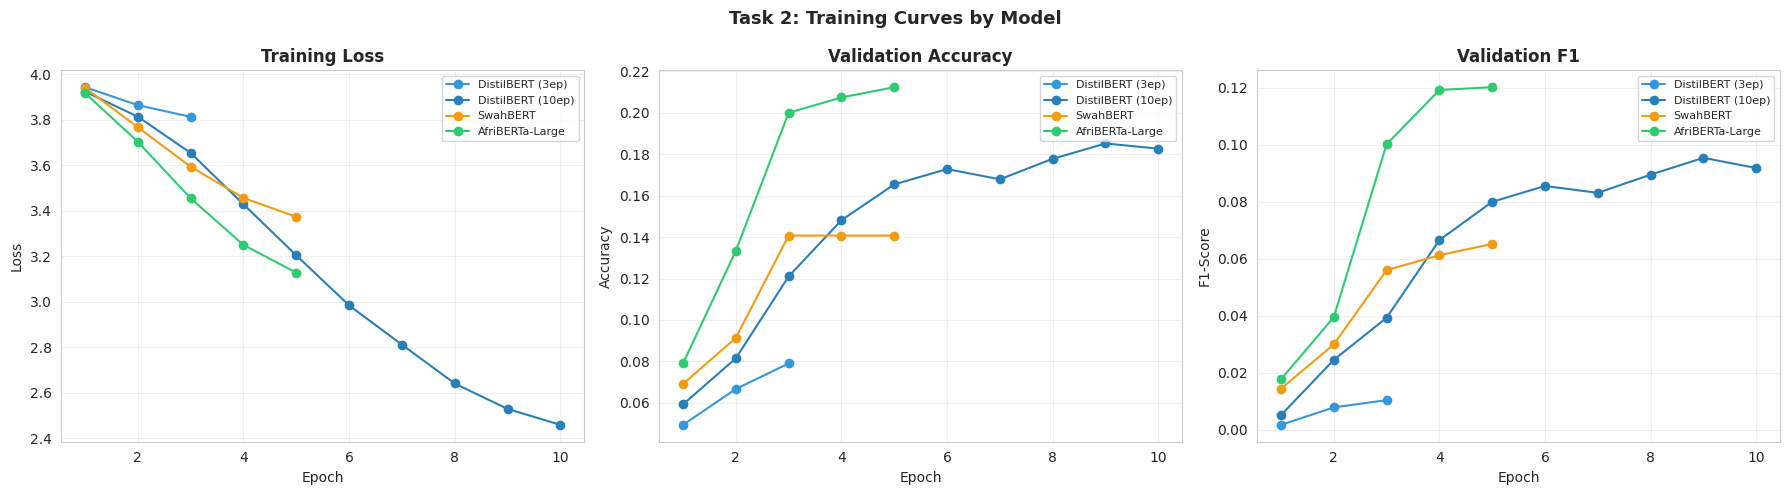

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

experiments = [
    (result_distil_a,  '#3498db', 'DistilBERT (3ep)'),
    (result_distil_b,  '#2980b9', 'DistilBERT (10ep)'),
    (result_swahbert,  '#f39c12', 'SwahBERT'),
    (result_afriberta, '#2ecc71', 'AfriBERTa-Large'),
]

for res, color, label in experiments:
    h = res['history']
    axes[0].plot(h['epoch'], h['train_loss'], marker='o', color=color, label=label)
    axes[1].plot(h['epoch'], h['val_acc'],    marker='o', color=color, label=label)
    axes[2].plot(h['epoch'], h['val_f1'],     marker='o', color=color, label=label)

for ax, title, ylabel in zip(
    axes,
    ['Training Loss', 'Validation Accuracy', 'Validation F1'],
    ['Loss', 'Accuracy', 'F1-Score']
):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Task 2: Training Curves by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Task 1 best results (from your notebook)
task1_results = [
    {'method': 'TF-IDF',          'task': 'Task 1', 'test_acc': None, 'test_f1': None},
    {'method': 'Word2Vec (1ep)',   'task': 'Task 1', 'test_acc': None, 'test_f1': None},
    {'method': 'Word2Vec (10ep)',  'task': 'Task 1', 'test_acc': None, 'test_f1': None},
    {'method': 'FastText',         'task': 'Task 1', 'test_acc': None, 'test_f1': None},
    {'method': 'Char N-grams',     'task': 'Task 1', 'test_acc': None, 'test_f1': None},
]

# ⚠️ FILL IN YOUR TASK 1 RESULTS BELOW
# Replace None with your actual Task 1 test accuracy and F1 scores
# e.g. {'method': 'TF-IDF', 'task': 'Task 1', 'test_acc': 0.35, 'test_f1': 0.28}

print("⚠️  Please fill in your Task 1 results above before running Cell 14!")
print("Run this in your Task 1 notebook to get the values:")
print()
print("  print(results_df[['val_acc', 'val_f1', 'test_acc', 'test_f1']].to_string())")

⚠️  Please fill in your Task 1 results above before running Cell 14!
Run this in your Task 1 notebook to get the values:

  print(results_df[['val_acc', 'val_f1', 'test_acc', 'test_f1']].to_string())



TASK 1 vs TASK 2 — FULL COMPARISON
                        method   task  test_acc  test_f1
                        TF-IDF Task 1  0.240100 0.220300
                Word2Vec (1ep) Task 1  0.076100 0.014600
               Word2Vec (10ep) Task 1  0.055300 0.005400
                      FastText Task 1  0.047400 0.002100
                  Char N-grams Task 1  0.214400 0.206800
     DistilBERT (3ep, lr=2e-5) Task 2  0.069170 0.010058
    DistilBERT (10ep, lr=3e-5) Task 2  0.149209 0.090946
       SwahBERT (5ep, lr=2e-5) Task 2  0.121542 0.050531
AfriBERTa-Large (5ep, lr=2e-5) Task 2  0.201581 0.111270


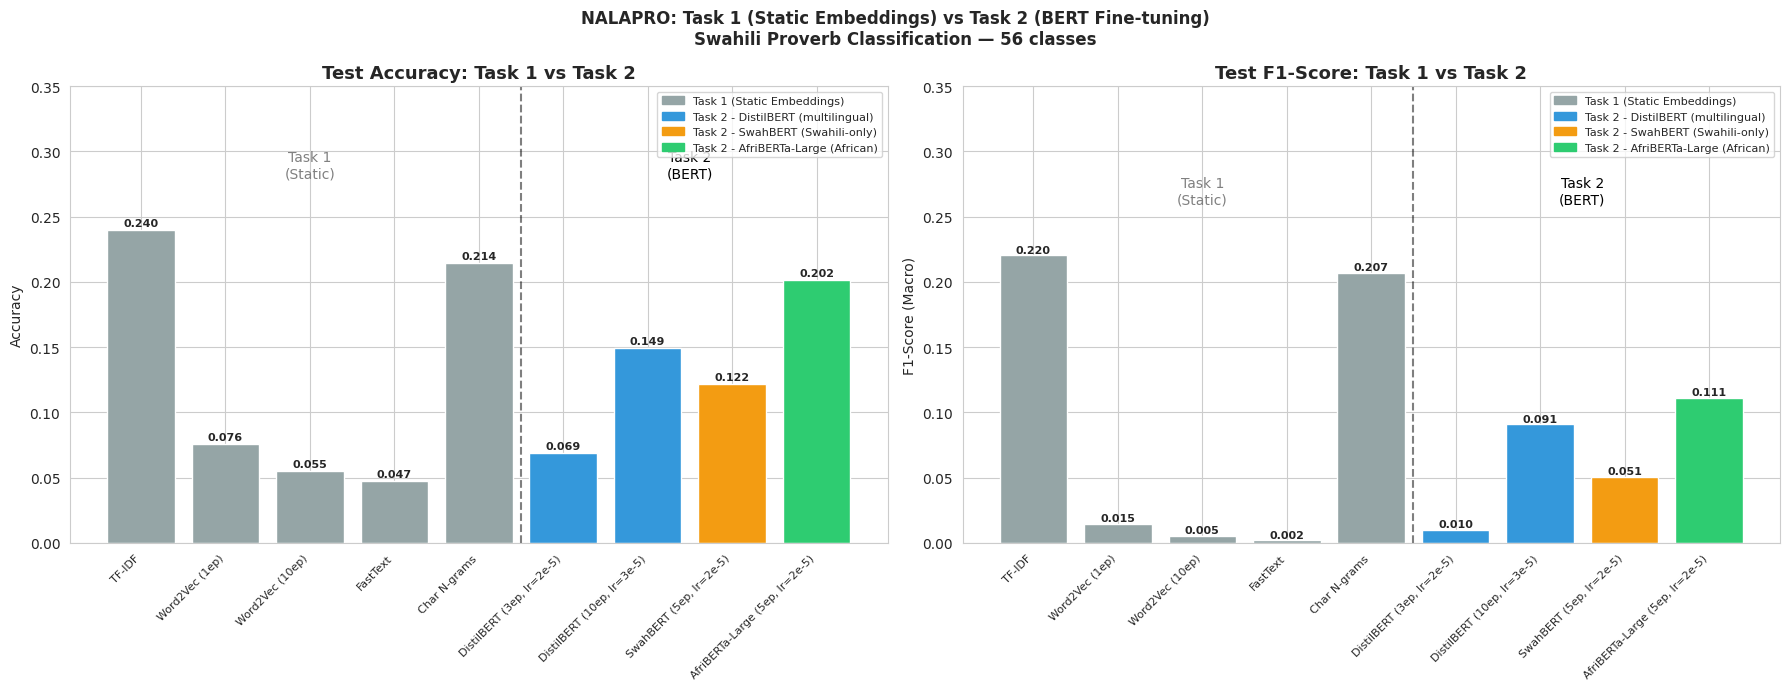


KEY FINDINGS
Task 1 Best (Acc): TF-IDF           → 0.2401
Task 1 Best (F1):  TF-IDF           → 0.2203
Task 2 Best (Acc): AfriBERTa-Large  → 0.2016
Task 2 Best (F1):  AfriBERTa-Large  → 0.1113

Improvement (Acc): -3.9%
Improvement (F1):  -10.9%

✓ Full comparison saved!


In [ ]:
# Task 1 results from your notebook
task1_results = [
    {'method': 'TF-IDF',         'task': 'Task 1', 'test_acc': 0.2401, 'test_f1': 0.2203},
    {'method': 'Word2Vec (1ep)', 'task': 'Task 1', 'test_acc': 0.0761, 'test_f1': 0.0146},
    {'method': 'Word2Vec (10ep)','task': 'Task 1', 'test_acc': 0.0553, 'test_f1': 0.0054},
    {'method': 'FastText',       'task': 'Task 1', 'test_acc': 0.0474, 'test_f1': 0.0021},
    {'method': 'Char N-grams',   'task': 'Task 1', 'test_acc': 0.2144, 'test_f1': 0.2068},
]

task2_results = [
    {'method': result_distil_a['config'],  'task': 'Task 2', 'test_acc': result_distil_a['test_acc'],  'test_f1': result_distil_a['test_f1']},
    {'method': result_distil_b['config'],  'task': 'Task 2', 'test_acc': result_distil_b['test_acc'],  'test_f1': result_distil_b['test_f1']},
    {'method': result_swahbert['config'],  'task': 'Task 2', 'test_acc': result_swahbert['test_acc'],  'test_f1': result_swahbert['test_f1']},
    {'method': result_afriberta['config'], 'task': 'Task 2', 'test_acc': result_afriberta['test_acc'], 'test_f1': result_afriberta['test_f1']},
]

all_df = pd.DataFrame(task1_results + task2_results)

print('\n' + '='*60)
print('TASK 1 vs TASK 2 — FULL COMPARISON')
print('='*60)
print(all_df.to_string(index=False))

# Colors
bar_colors = []
for _, row in all_df.iterrows():
    if row['task'] == 'Task 1':
        bar_colors.append('#95a5a6')
    elif 'DistilBERT' in row['method']:
        bar_colors.append('#3498db')
    elif 'SwahBERT' in row['method']:
        bar_colors.append('#f39c12')
    else:
        bar_colors.append('#2ecc71')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x = np.arange(len(all_df))

bars1 = axes[0].bar(x, all_df['test_acc'], color=bar_colors, edgecolor='white')
axes[0].set_title('Test Accuracy: Task 1 vs Task 2', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_df['method'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylim(0, max(all_df['test_acc'].max() + 0.08, 0.35))
axes[0].axvline(x=4.5, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[0].text(2,   all_df['test_acc'].max() + 0.04, 'Task 1\n(Static)', ha='center', fontsize=10, color='gray')
axes[0].text(6.5, all_df['test_acc'].max() + 0.04, 'Task 2\n(BERT)', ha='center', fontsize=10, color='black')
for bar, val in zip(bars1, all_df['test_acc']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.003,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

bars2 = axes[1].bar(x, all_df['test_f1'], color=bar_colors, edgecolor='white')
axes[1].set_title('Test F1-Score: Task 1 vs Task 2', fontweight='bold', fontsize=13)
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_df['method'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylim(0, max(all_df['test_f1'].max() + 0.08, 0.35))
axes[1].axvline(x=4.5, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1].text(2,   all_df['test_f1'].max() + 0.04, 'Task 1\n(Static)', ha='center', fontsize=10, color='gray')
axes[1].text(6.5, all_df['test_f1'].max() + 0.04, 'Task 2\n(BERT)', ha='center', fontsize=10, color='black')
for bar, val in zip(bars2, all_df['test_f1']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color='#95a5a6', label='Task 1 (Static Embeddings)'),
    mpatches.Patch(color='#3498db', label='Task 2 - DistilBERT (multilingual)'),
    mpatches.Patch(color='#f39c12', label='Task 2 - SwahBERT (Swahili-only)'),
    mpatches.Patch(color='#2ecc71', label='Task 2 - AfriBERTa-Large (African)'),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc='upper right')
axes[1].legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.suptitle('NALAPRO: Task 1 (Static Embeddings) vs Task 2 (BERT Fine-tuning)\nSwahili Proverb Classification — 56 classes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print('\n' + '='*60)
print('KEY FINDINGS')
print('='*60)
print(f'Task 1 Best (Acc): TF-IDF           → 0.2401')
print(f'Task 1 Best (F1):  TF-IDF           → 0.2203')
print(f'Task 2 Best (Acc): AfriBERTa-Large  → {result_afriberta["test_acc"]:.4f}')
print(f'Task 2 Best (F1):  AfriBERTa-Large  → {result_afriberta["test_f1"]:.4f}')
print(f'\nImprovement (Acc): {(result_afriberta["test_acc"] - 0.2401)*100:+.1f}%')
print(f'Improvement (F1):  {(result_afriberta["test_f1"]  - 0.2203)*100:+.1f}%')

all_df.to_csv('/tmp/task1_vs_task2_results.csv', index=False)
print('\n✓ Full comparison saved!')